# P2: Ley de Pzif
Veremos si un idioma artificial creado aleatoreamente cumple con la ley de Pzif, y veremos como se comporta una lengua con pocos recursos digitales.

In [1]:
# Importamos las librerías necesarias
import random
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import minimize
import matplotlib.pyplot as plt

## Generando un idioma artificial.

In [26]:
# Definimos el alfabeto y la longitud de las palabras (con un espacio)
alfabeto = "abcdefghijklmnñopqrstuvwxyz "
letras_sueltas = np.random.choice(list(alfabeto), size=5000000, replace=True)
chorizo_de_letras = "".join(letras_sueltas)
texto_artificial = chorizo_de_letras.split()

In [27]:
# Longitud de nuestro texto artificial, 
len(texto_artificial)

171789

In [35]:
conteo = Counter(texto_artificial)

In [36]:
df = pd.DataFrame(conteo.items(), columns = ["Palabras","Frecuencia"])

In [43]:
# DataFrame ordenado 
df_ord = df.sort_values("Frecuencia", ascending = False,).copy()
df_ord["Rango"] = range(1,len(df_ord)+1)
df_ord.head(20)

,Palabras,Frecuencia,Rango
540,m,252,1
273,x,244,2
1122,l,244,3
662,o,242,4
2616,b,241,5
272,a,241,6
731,h,237,7
804,y,237,8
698,v,231,9
1026,q,231,10


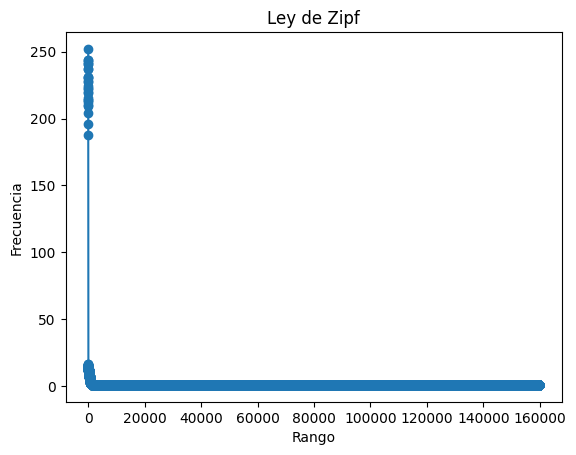

In [46]:
plt.plot(df_ord["Rango"],df_ord["Frecuencia"],marker = "o")
plt.title("Ley de Zipf")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

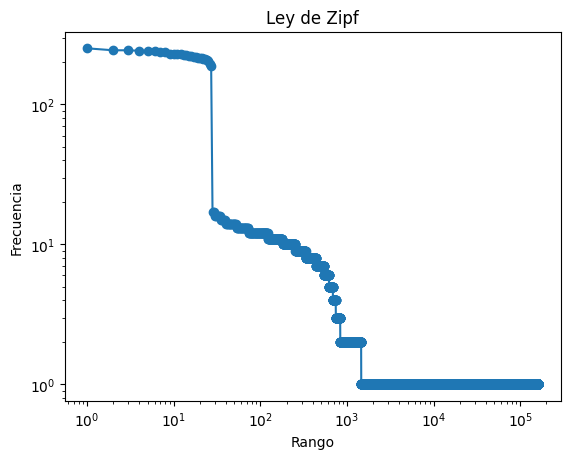

In [47]:
plt.loglog(df_ord["Rango"], df_ord["Frecuencia"], marker="o")
plt.title("Ley de Zipf(Log-Log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

## Estimando el parametro alfa (usando el notebook de clase)

In [48]:
ranks = np.array(df_ord["Rango"])
frequencies = np.array(df_ord["Frecuencia"])

In [50]:
def zipf_minimization_objective(
    alpha: np.float64, word_ranks: np.ndarray, word_frequencies: np.ndarray
) -> np.float64:
    predicted_log_freq = np.log(word_frequencies[0]) -alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

In [51]:
initial_alpha_guess = 1.0

optimization_result = minimize(
    zipf_minimization_objective,
    initial_alpha_guess,
    args=(ranks, frequencies)
)

estimated_alpha = optimization_result.x[0]

mean_squared_error = zipf_minimization_objective(
    estimated_alpha, ranks, frequencies
)

print(f"Estimated alpha: {estimated_alpha:.4f}")
print(f"Mean Squared Error: {mean_squared_error:.4f}")

Estimated alpha: 0.4987
Mean Squared Error: 33013.3888


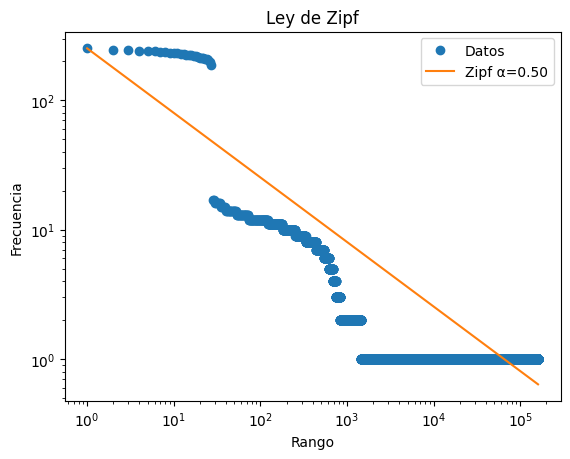

In [52]:
plt.loglog(ranks, frequencies, "o", label="Datos")

zipf_fit = frequencies[0] * ranks**(-estimated_alpha)

plt.loglog(ranks, zipf_fit, label=f"Zipf α={estimated_alpha:.2f}")

plt.title("Ley de Zipf")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()

## Analizando un corpus con pocos recursos digitales
Analizaremos una biblia de Tzotzil de los altos de chiapas, exáctamente del Tzotzil de Zinacantán.

In [58]:
import pdfplumber
texto = ""
with pdfplumber.open("biblia_tzotzil.pdf") as pdf:
    for pagina in pdf.pages:
        texto += pagina.extract_text() + "\n"
texto = texto.lower()

In [68]:
import re
texto = re.sub(r"\d+", "", texto)
texto = re.sub(r"[^\w\s']", " ", texto)
texto_l = texto.split()
conteo_tzo = Counter(texto_l)
conteo_tzo.most_common(20)

[('ti', 39490),
 ('ta', 24887),
 ('jech', 8456),
 ('laj', 6574),
 ('jaꞌ', 4937),
 ('yuꞌun', 4445),
 ('mu', 2503),
 ('tey', 2302),
 ('diose', 2196),
 ('oy', 2154),
 ('jesuse', 2065),
 ('mi', 2039),
 ('cꞌalal', 1966),
 ('cꞌusi', 1947),
 ('xa', 1910),
 ('o', 1806),
 ('xal', 1535),
 ('buchꞌu', 1509),
 ('cꞌu', 1429),
 ('yoꞌ', 1416)]

In [69]:
df_tzo = pd.DataFrame(conteo_tzo.items(), columns = ["Palabras","Frecuencia"])

In [70]:
df_tzo.head(20)

,Palabras,Frecuencia
0,ti,39490
1,achꞌ,342
2,rextomento,4
3,yuꞌun,4445
4,jesucristoe,259
5,el,1054
6,nuevo,527
7,testamento,527
8,de,533
9,nuestro,1


In [72]:
# DataFrame ordenado 
df_ord_tzo = df_tzo.sort_values("Frecuencia", ascending = False,).copy()
df_ord_tzo["Rango"] = range(1,len(df_ord_tzo)+1)
df_ord_tzo.head(20)

,Palabras,Frecuencia,Rango
0,ti,39490,1
133,ta,24887,2
222,jech,8456,3
107,laj,6574,4
119,jaꞌ,4937,5
3,yuꞌun,4445,6
281,mu,2503,7
218,tey,2302,8
328,diose,2196,9
256,oy,2154,10


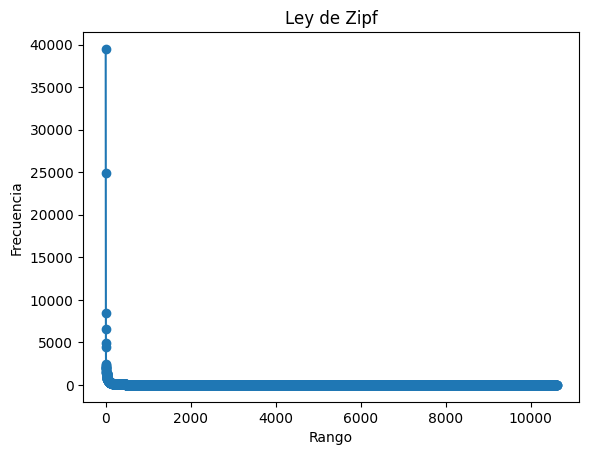

In [73]:
plt.plot(df_ord_tzo["Rango"],df_ord_tzo["Frecuencia"],marker = "o")
plt.title("Ley de Zipf")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

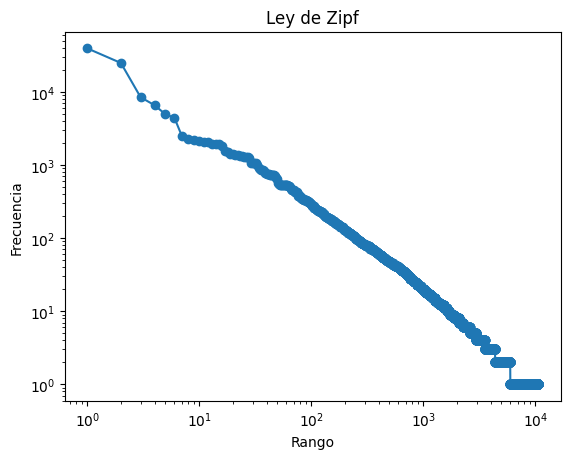

In [74]:
plt.loglog(df_ord_tzo["Rango"],df_ord_tzo["Frecuencia"],marker = "o")
plt.title("Ley de Zipf (log-log)")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()